# Efficiency comparison of s-stage IRKGL schemes ( Henon Heiles)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.2**:

    - **Figure 2(c)**, saved as **`Fig5.pdf`**
    - **Figure 2(d)**, saved as **`Fig6.pdf`**



<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Hénon-Heiles">Initial value problem: Hénon-Heiles</a></li> 
    <li><a href="#IRKGL16-integrations">IRKGL16 integrations</a></li>
    <li><a href="#Figures">Figures</a></li>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre

Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater


v"0.2.13"

### Utils

In [2]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Initial value problem: Hénon-Heiles

We consider the Hénon-Heiles model which is Hamiltonian with

\begin{align*}
H(q,p)=\frac{1}{2} (p_1^2+p_2^2)+\frac{1}{2}(q_1^2+q_2^2)+q_1^2q_2-\frac{1}{3}q_2^3
\end{align*}

and the corresponding system

\begin{align*}
& \frac{dq_1}{dt}=p_1, \quad 
\frac{dq_2}{dt}=p_2, \\
& \frac{dp_1}{dt}=-q_1-2q_1q_2, \quad 
 \frac{dp_2}{dt}=-q_2-q_1^2+q_2^2
\end{align*}

In [3]:
function Potential_U(q1,q2)


    return 1/2*(q1*q1+q2*q2)+q1*q1*q2-1/3*q2*q2*q2

end

function HenonHeliesHam(u,parms)

    q1=u[1]
    q2=u[2]
    p1=u[3]
    p2=u[4]
    
    U=Potential_U(q1,q2)
    
    return 1/2*(p1*p1+p2*p2)+U

end


function HenonHeliesHam(u)

    return HenonHeliesHam(u,[])

end

function HenonHeilesODE!(du,u,parms,t)

  q1=u[1]
  q2=u[2]
  p1=u[3]
  p2=u[4]

  du[1]=p1
  du[2]=p2
  
  du[3]=-q1-2*q1*q2
  du[4]=-q2-q1*q1+q2*q2
  
  return nothing
  
end

HenonHeilesODE! (generic function with 1 method)

In [4]:
# Gemetric Numerical Integration. Structure-Preserving Algorithms for Ordinary Differential Equations, page 15

q0=[0,3/10]
p0=[0, 2/10]

# Non-Chaotic solution H0=1/12

H0=1/12
U0=Potential_U(q0[1],q0[2])
p0[1]=sqrt(2*H0-2*U0-p0[2]^2)
parms = [0.]

u0=vcat(q0,p0)
u0_B=BigFloat.(u0)

t0 = 0.
tF = 2*pi*1e4
tspan=(t0,tF)

prob = ODEProblem{true,SciMLBase.FullSpecialize}(HenonHeilesODE!, u0, tspan, parms)

HAM=HenonHeliesHam
@show(HAM(u0, parms));

HAM(u0, parms) = 0.08333333333333333


##### <a href="#top">Back to the top</a>

## IRKGL16 integrations

### Comparison of IRKGL schemes

In [5]:
ddt0_irk16=collect(1/4:1/4:3)  

println("simd")
alg=IRKGL16(simd=true, fseq=false, second_order_ode=true)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq")
alg=IRKGL16(simd=false, fseq=true, second_order_ode=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybr")
alg=IRKGL16(simd=true, fseq=true, second_order_ode=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);


simd
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0
seq
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0
hybr
,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


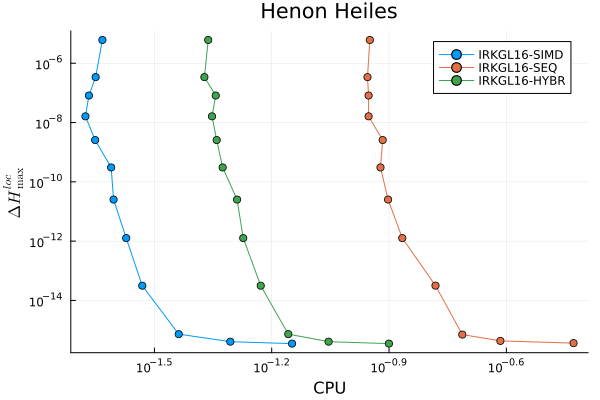

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [6]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL12 integrations (s=6)

In [7]:
ddt0_irk12=ddt0_irk16*3/4 
steps_irk12=tF./ddt0_irk12

println("simd")
alg=IRKGL16(s=6, simd=true, fseq=false, second_order_ode=true)
sols_irk12_simd=run_many_IRKGL16(alg, prob, ddt0_irk12, HAM)
#
println("seq")
alg=IRKGL16(s=6, simd=false, fseq=true, second_order_ode=true)
sols_irk12_seq=run_many_IRKGL16(alg,prob,ddt0_irk12,HAM)
#
println("hybr")
alg=IRKGL16(s=6, simd=true, fseq=true, second_order_ode=true)
sols_irk12_hyb=run_many_IRKGL16(alg,prob,ddt0_irk12,HAM);


simd
,0.1875,0.375,0.5625,0.75,0.9375,1.125,1.3125,1.5,1.6875,1.875,2.0625,2.25
seq
,0.1875,0.375,0.5625,0.75,0.9375,1.125,1.3125,1.5,1.6875,1.875,2.0625,2.25
hybr
,0.1875,0.375,0.5625,0.75,0.9375,1.125,1.3125,1.5,1.6875,1.875,2.0625,2.25


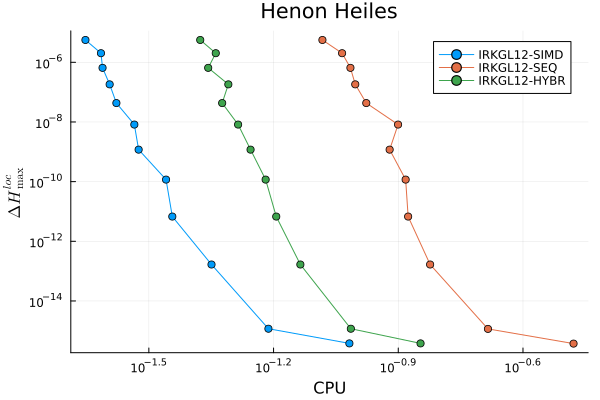

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [8]:
#
sols2plot=[sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb]
labels2plot=["IRKGL12-SIMD", "IRKGL12-SEQ", "IRKGL12-HYBR"]

pl_=plot(title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL8 integrations (s=4)

In [9]:
ddt0_irk8=ddt0_irk16/2  
steps_irk8=tF./ddt0_irk8

println("simd")
alg=IRKGL16(s=4, simd=true, fseq=false, second_order_ode=true)
sols_irk8_simd=run_many_IRKGL16(alg, prob, ddt0_irk8, HAM)
#
println("seq")
alg=IRKGL16(s=4, simd=false, fseq=true, second_order_ode=true)
sols_irk8_seq=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM)
#
println("hybr")
alg=IRKGL16(s=4, simd=true, fseq=true, second_order_ode=true)
sols_irk8_hyb=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM);


simd
,0.125,0.25,0.375,0.5,0.625,0.75,0.875,1.0,1.125,1.25,1.375,1.5
seq
,0.125,0.25,0.375,0.5,0.625,0.75,0.875,1.0,1.125,1.25,1.375,1.5
hybr
,0.125,0.25,0.375,0.5,0.625,0.75,0.875,1.0,1.125,1.25,1.375,1.5


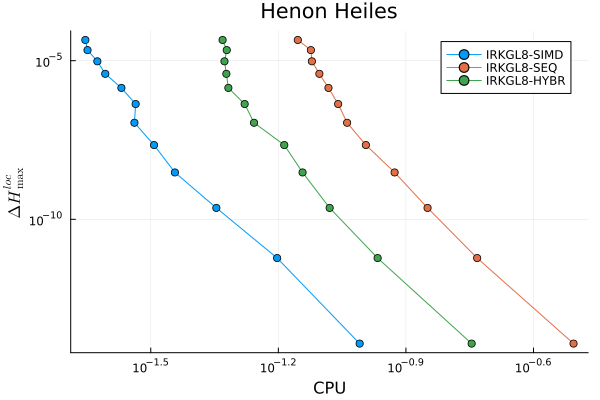

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [10]:
#
sols2plot=[sols_irk8_simd, sols_irk8_seq, sols_irk8_hyb]
labels2plot=["IRKGL8-SIMD", "IRKGL8-SEQ", "IRKGL8-HYBR"]

pl_=plot(title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL4 integrations (s=2)

In [11]:
ddt0_irk4=ddt0_irk16/4
steps_irk4=tF./ddt0_irk4

println("simd")
alg=IRKGL16(s=2, simd=true, fseq=false, second_order_ode=true)
sols_irk4_simd=run_many_IRKGL16(alg, prob, ddt0_irk4, HAM)
#
println("seq")
alg=IRKGL16(s=2, simd=false, fseq=true, second_order_ode=true)
sols_irk4_seq=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM)
#
println("hybr")
alg=IRKGL16(s=2, simd=true, fseq=true, second_order_ode=true)
sols_irk4_hyb=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM);


simd
,0.0625,0.125,0.1875,0.25,0.3125,0.375,0.4375,0.5,0.5625,0.625,0.6875,0.75
seq
,0.0625,0.125,0.1875,0.25,0.3125,0.375,0.4375,0.5,0.5625,0.625,0.6875,0.75
hybr
,0.0625,0.125,0.1875,0.25,0.3125,0.375,0.4375,0.5,0.5625,0.625,0.6875,0.75


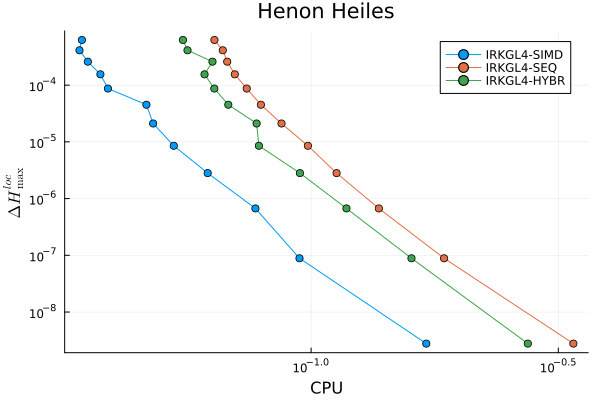

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [12]:
#
sols2plot=[sols_irk4_simd, sols_irk4_seq, sols_irk4_hyb]
labels2plot=["IRKGL4-SIMD", "IRKGL4-SEQ", "IRKGL4-HYBR"]

pl_=plot(title="Henon Heiles", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

## Figures

In [13]:
sols2plot=[sols_irk16_simd, sols_irk16_seq,
           sols_irk12_simd, sols_irk12_seq,
           sols_irk8_simd, sols_irk8_seq,
           sols_irk4_simd, sols_irk4_seq
           ]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", 
             "IRKGL12-SIMD", "IRKGL12-SEQ",
             "IRKGL8-SIMD", "IRKGL8-SEQ",
             "IRKGL4-SIMD", "IRKGL4-SEQ"
]


labels2plot_=["IRKGL16", "IRKGL16", 
             "IRKGL12", "IRKGL12",
             "IRKGL8", "IRKGL8",
             "IRKGL4", "IRKGL4"
]

markershape2plot=[:circle, :xcross, :circle, :xcross, 
                  :circle, :xcross, :circle, :xcross]


ls2plot=[:solid, :solid, :solid, :solid, 
         :solid, :solid, :solid, :solid]

#colors2plot = [:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal, :gold]
colors2plot = [:red, :red, :blue, :blue, 
               :green, :green, :orange, :orange]

stages = [8,8,6,6,4,4,2,2];

### Figure5

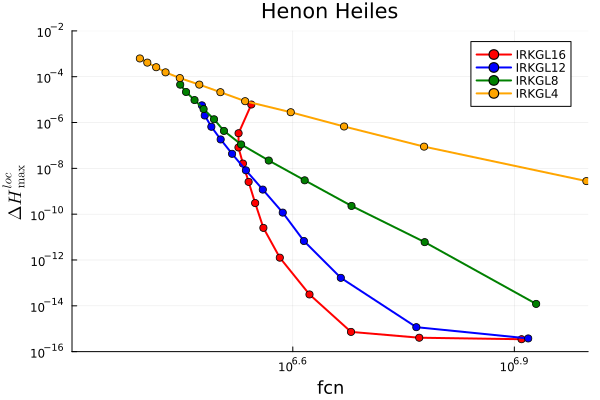

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [14]:
yrange=(1e-16, 1e-2)
xrange=(2e6,1e7)

pl3=plot(scale=:log10,
         xlimits=xrange, ylimits=yrange,    
         title="Henon Heiles", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:topright,
         guidefont=font(12), labelsize=10)

for i in 1:2:length(sols2plot)
       
    sols=sols2plot[i]
    fcn=stages[i]*(sols.iters)
    #fcn=sols.fcns
    plot!(pl3, fcn , sols.MaxΔHlocal,
          markershape=:circle, lw=2,
          label=labels2plot_[i], color=colors2plot[i])
end

display(pl3)

In [15]:
savefig("./figures/Fig5.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig5.pdf"

### Figure6

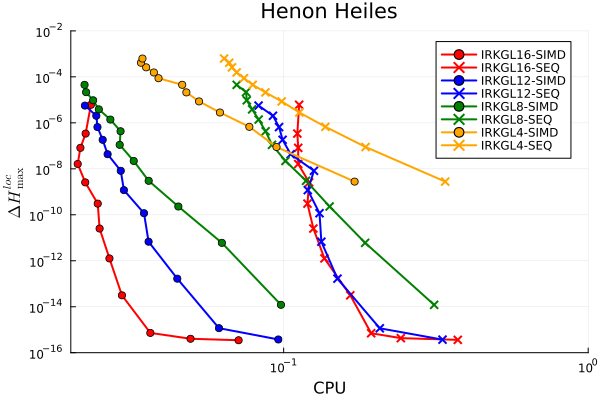

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [16]:
yrange=(1e-16, 1e-2)
xrange=(2e-2,1e0)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=markershape2plot[1], lw=2, ls=ls2plot[1],
          ylimits=yrange, xlimits=xrange,
          label=labels2plot[1], color=colors2plot[1],
          legend=:topright,
           title="Henon Heiles",  xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
        markershape=markershape2plot[i], lw=2, ls=ls2plot[i],
        label=labels2plot[i], color=colors2plot[i],
        scale=:log10)
    
end

plot(pl1)


In [17]:
savefig("./figures/Fig6.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-2-Efficiency comparison of s-stage IRKGL schemes/figures/Fig6.pdf"